In [1]:
!pip install deepxde torch numpy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [2]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
import torch

# --- Config ---
ALPHA      = 1.0    # thermal diffusivity
T_MAX      = 0.1    # simulation end time (kept short: solution decays as exp(-2π²αt))
N_DOMAIN   = 10000  # interior collocation points (LHS)
N_BOUNDARY = 800    # spatial boundary points (200 per edge)
N_INITIAL  = 500    # IC points at t=0
W_PDE = 1           # loss weight: PDE residual
W_BC  = 10          # loss weight: boundary condition
W_IC  = 10          # loss weight: initial condition
T_EVAL = [0.025, 0.05, 0.075]  # snapshots where solution amplitude is still 0.14-0.61

print(f"Backend: {dde.backend.backend_name}")
print(f"T_MAX={T_MAX}, decay at T_MAX: exp(-2π²α·T_MAX) = {np.exp(-2*np.pi**2*ALPHA*T_MAX):.3f}")
print("Config loaded.")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Backend: pytorch
T_MAX=0.1, decay at T_MAX: exp(-2π²α·T_MAX) = 0.139
Config loaded.


In [3]:
def T_exact(x, y, t):
    """Exact solution: T = sin(πx)·sin(πy)·exp(−2π²αt)"""
    return np.sin(np.pi * x) * np.sin(np.pi * y) * np.exp(-2 * np.pi**2 * ALPHA * t)

# Sanity check: at t=0, T_exact should equal the IC
x_test = np.array([0.5])
y_test = np.array([0.5])
val_at_t0 = T_exact(x_test, y_test, 0.0)
val_ic    = np.sin(np.pi * 0.5) * np.sin(np.pi * 0.5)
print(f"T_exact(0.5, 0.5, 0) = {val_at_t0[0]:.6f}")
print(f"sin(π·0.5)²          = {val_ic:.6f}")
assert np.isclose(val_at_t0[0], val_ic), "Analytical solution does not match IC"
print("Sanity check passed.")

T_exact(0.5, 0.5, 0) = 1.000000
sin(π·0.5)²          = 1.000000
Sanity check passed.


In [4]:
# Spatial domain: unit square [0,1] x [0,1]
geom = dde.geometry.Rectangle(xmin=[0, 0], xmax=[1, 1])

# Time domain: [0, T_MAX]
timedomain = dde.geometry.TimeDomain(0, T_MAX)

# Combined space-time domain
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

print(f"Time domain: [0, {T_MAX}]")
print("GeometryXTime created successfully.")

Time domain: [0, 0.1]
GeometryXTime created successfully.


In [5]:
def pde(x, u):
    """
    Residual of: ∂u/∂t - α(∂²u/∂x² + ∂²u/∂y²) = 0
    x[:, 0] = x_coord, x[:, 1] = y_coord, x[:, 2] = t
    """
    u_t  = dde.grad.jacobian(u, x, i=0, j=2)          # ∂u/∂t
    u_xx = dde.grad.hessian(u, x, component=0, i=0, j=0)  # ∂²u/∂x²
    u_yy = dde.grad.hessian(u, x, component=0, i=1, j=1)  # ∂²u/∂y²
    return u_t - ALPHA * (u_xx + u_yy)

print("PDE residual function defined.")

PDE residual function defined.


In [6]:
# Dirichlet BC: T = 0 on all spatial boundaries for all t
def on_boundary(x, on_boundary):
    return on_boundary

bc = dde.icbc.DirichletBC(
    geomtime,
    func=lambda x: np.zeros((len(x), 1)),
    on_boundary=on_boundary,
)

# IC: T(x, y, 0) = sin(πx)·sin(πy)
def ic_func(x):
    return np.sin(np.pi * x[:, 0:1]) * np.sin(np.pi * x[:, 1:2])

ic = dde.icbc.IC(
    geomtime,
    func=ic_func,
    on_initial=lambda x, on_initial: on_initial,
)

print("Boundary condition (Dirichlet, T=0) defined.")
print("Initial condition (sin(πx)·sin(πy)) defined.")

Boundary condition (Dirichlet, T=0) defined.
Initial condition (sin(πx)·sin(πy)) defined.


In [7]:
def solution_func(x):
    """Analytical solution for DeepXDE test metric: x has columns [x_coord, y_coord, t]"""
    return (np.sin(np.pi * x[:, 0:1])
          * np.sin(np.pi * x[:, 1:2])
          * np.exp(-2 * np.pi**2 * ALPHA * x[:, 2:3]))

data = dde.data.TimePDE(
    geometryxtime=geomtime,
    pde=pde,
    ic_bcs=[bc, ic],
    num_domain=N_DOMAIN,
    num_boundary=N_BOUNDARY,
    num_initial=N_INITIAL,
    train_distribution="LHS",
    solution=solution_func,
    num_test=1000,
)

print("Training dataset assembled:")
print(f"  Domain points : {N_DOMAIN}")
print(f"  Boundary pts  : {N_BOUNDARY}")
print(f"  IC points     : {N_INITIAL}")
print(f"  Test points   : 1000 (evaluated against analytical solution)")

Training dataset assembled:
  Domain points : 10000
  Boundary pts  : 800
  IC points     : 500
  Test points   : 1000 (evaluated against analytical solution)


In [8]:
# FNN: [3, 32, 32, 32, 32, 32, 1] with tanh activations
layer_sizes = [3] + [32] * 5 + [1]
net = dde.nn.FNN(layer_sizes, "tanh", "Glorot normal")

model = dde.Model(data, net)

total_params = sum(p.numel() for p in net.parameters())
print(f"Network: {layer_sizes}")
print(f"Activation: tanh")
print(f"Total parameters: {total_params:,}")

Network: [3, 32, 32, 32, 32, 32, 1]
Activation: tanh
Total parameters: 4,385


Compiling model...
'compile' took 0.000523 s



Training model...



Step      Train loss                        Test loss                         Test metric


0         [1.82e-01, 5.65e-03, 2.74e+00]    [1.86e-01, 5.65e-03, 2.74e+00]    []  


1000      [6.08e-02, 8.33e-02, 1.16e-01]    [3.10e-02, 8.33e-02, 1.16e-01]    []  


...

7000      [1.44e-02, 4.36e-03, 6.25e-03]    [1.12e-02, 4.36e-03, 6.25e-03]    []  


8000      [4.13e-03, 3.18e-03, 3.08e-03]    [2.71e-03, 3.18e-03, 3.08e-03]    []  


9000      [2.20e-03, 2.56e-03, 1.81e-03]    [1.31e-03, 2.56e-03, 1.81e-03]    []  


10000     [2.05e-03, 2.15e-03, 1.36e-03]    [1.48e-03, 2.15e-03, 1.36e-03]    []  



Best model at step 10000:
  train loss: 5.56e-03
  test loss: 4.99e-03
  test metric: []

'train' took 274.803914 s



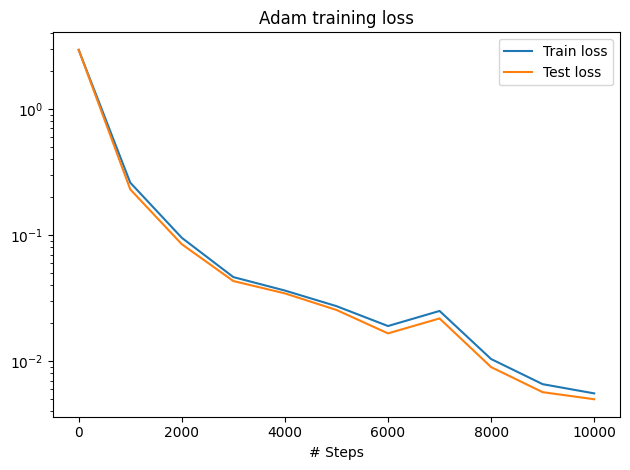

Adam training complete.


In [9]:
model.compile(
    "adam",
    lr=1e-3,
    loss_weights=[W_PDE, W_BC, W_IC],
)

losshistory, train_state = model.train(iterations=10000)

dde.utils.plot_loss_history(losshistory)
plt.title("Adam training loss")
plt.tight_layout()
plt.show()
print("Adam training complete.")

Compiling model...
'compile' took 0.000283 s



Training model...

Step      Train loss                        Test loss                         Test metric


10000     [2.05e-03, 2.15e-03, 1.36e-03]    [1.48e-03, 2.15e-03, 1.36e-03]    []  


11000     [8.68e-05, 6.98e-05, 2.76e-05]    [4.60e-05, 6.98e-05, 2.76e-05]    []  


12000     [3.58e-05, 2.85e-05, 9.49e-06]    [1.99e-05, 2.85e-05, 9.49e-06]    []  


13000     [1.76e-05, 1.18e-05, 3.62e-06]    [1.04e-05, 1.18e-05, 3.62e-06]    []  


13643     [1.23e-05, 8.69e-06, 1.91e-06]    [7.21e-06, 8.69e-06, 1.91e-06]    []  



Best model at step 13643:
  train loss: 2.29e-05
  test loss: 1.78e-05
  test metric: []

'train' took 330.210056 s



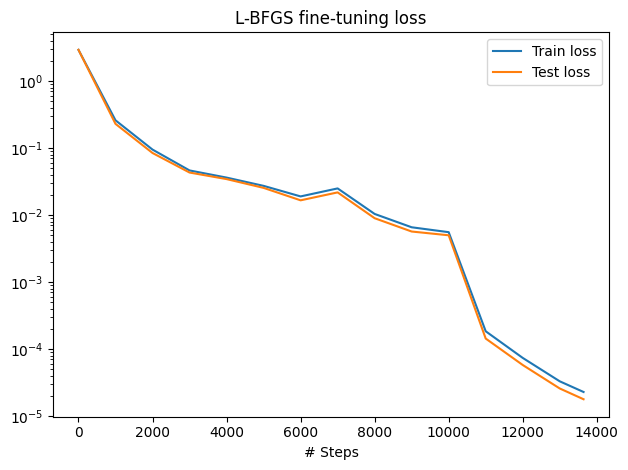

L-BFGS fine-tuning complete.


In [10]:
model.compile("L-BFGS", loss_weights=[W_PDE, W_BC, W_IC])
losshistory, train_state = model.train()

dde.utils.plot_loss_history(losshistory)
plt.title("L-BFGS fine-tuning loss")
plt.tight_layout()
plt.show()
print("L-BFGS fine-tuning complete.")

     t |   Rel. L2 error
-------------------------
  0.03 |        1.68e-03
  0.05 |        2.49e-03
  0.07 |        2.66e-03


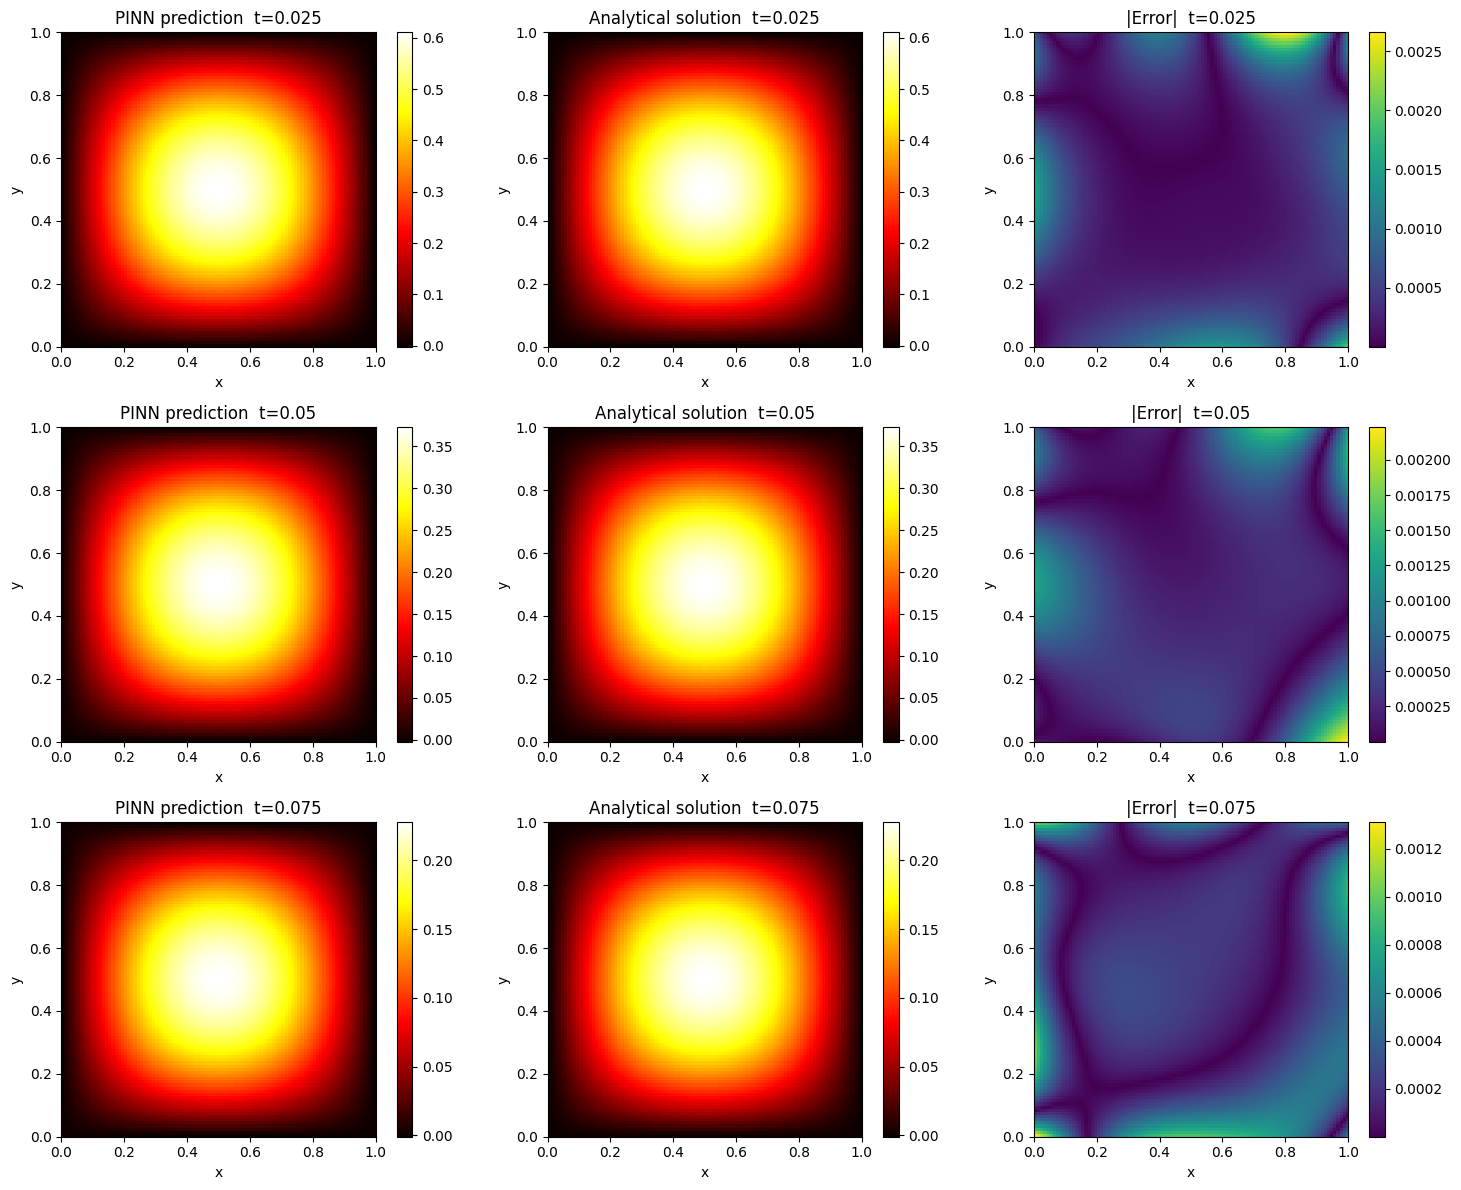

Evaluation complete. Figure saved to pinn_2d_results.png


In [11]:
# Dense evaluation grid
x_lin = np.linspace(0, 1, 100)
y_lin = np.linspace(0, 1, 100)
X, Y = np.meshgrid(x_lin, y_lin)

print(f"{'t':>6} | {'Rel. L2 error':>15}")
print("-" * 25)

fig, axes = plt.subplots(len(T_EVAL), 3, figsize=(15, 4 * len(T_EVAL)))

for row, t_val in enumerate(T_EVAL):
    t_arr = np.full(X.shape, t_val)
    pts   = np.column_stack([X.ravel(), Y.ravel(), t_arr.ravel()])

    T_pred = model.predict(pts).reshape(100, 100)
    T_true = T_exact(X, Y, t_val)
    error  = np.abs(T_pred - T_true)

    l2 = np.linalg.norm(T_pred - T_true) / np.linalg.norm(T_true)
    print(f"{t_val:>6.2f} | {l2:>15.2e}")

    vmin = min(T_pred.min(), T_true.min())
    vmax = max(T_pred.max(), T_true.max())

    im0 = axes[row, 0].imshow(T_pred, origin="lower", extent=[0,1,0,1],
                               vmin=vmin, vmax=vmax, cmap="hot")
    axes[row, 0].set_title(f"PINN prediction  t={t_val}")
    axes[row, 0].set_xlabel("x"); axes[row, 0].set_ylabel("y")
    plt.colorbar(im0, ax=axes[row, 0])

    im1 = axes[row, 1].imshow(T_true, origin="lower", extent=[0,1,0,1],
                               vmin=vmin, vmax=vmax, cmap="hot")
    axes[row, 1].set_title(f"Analytical solution  t={t_val}")
    axes[row, 1].set_xlabel("x"); axes[row, 1].set_ylabel("y")
    plt.colorbar(im1, ax=axes[row, 1])

    im2 = axes[row, 2].imshow(error, origin="lower", extent=[0,1,0,1],
                               cmap="viridis")
    axes[row, 2].set_title(f"|Error|  t={t_val}")
    axes[row, 2].set_xlabel("x"); axes[row, 2].set_ylabel("y")
    plt.colorbar(im2, ax=axes[row, 2])

plt.tight_layout()
plt.savefig("pinn_2d_results.png", dpi=150)
plt.show()
print("Evaluation complete. Figure saved to pinn_2d_results.png")